<a href="https://colab.research.google.com/github/Emsnehh/AI-Resume-Screener-and-Job-Match-Engine/blob/main/major_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Suppress all pip warnings
import warnings
warnings.filterwarnings('ignore')

import subprocess, sys

def install(package):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", package],
                   capture_output=True)

packages = [
    "nltk", "sentence-transformers", "scikit-learn",
    "PyMuPDF", "python-docx", "wordcloud", "plotly", "pandas", "numpy"
]

for p in packages:
    install(p)

# spaCy model
subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"],
               capture_output=True)

# NLTK data
import nltk
for pkg in ['punkt', 'stopwords', 'wordnet', 'averaged_perceptron_tagger', 'punkt_tab']:
    nltk.download(pkg, quiet=True)

print("✅ All libraries installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 10.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 47.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ All libraries installed!
✅ All libraries installed successfully!


In [ ]:
import re, os, warnings
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

import spacy
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

import fitz
from docx import Document

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from IPython.display import display, HTML

nlp = spacy.load('en_core_web_sm')
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

print("⏳ Loading BERT model...")
bert_model = SentenceTransformer('all-MiniLM-L6-v2')
print("All models loaded!")

⏳ Loading BERT model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ All models loaded!


In [ ]:
def clean_text(text):
    if not text: return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'[\+\(]?[1-9][0-9 .\-\(\)]{8,}[0-9]', '', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_text(text):
    cleaned = clean_text(text)
    tokens = word_tokenize(cleaned)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

def extract_text_from_pdf(file_path):
    try:
        doc = fitz.open(file_path)
        text = "".join(page.get_text() for page in doc)
        doc.close()
        return text
    except Exception as e:
        return f"Error: {e}"

def extract_text_from_docx(file_path):
    try:
        doc = Document(file_path)
        return '\n'.join([p.text for p in doc.paragraphs])
    except Exception as e:
        return f"Error: {e}"

def extract_text(file_path):
    ext = os.path.splitext(file_path)[1].lower()
    if ext == '.pdf':            return extract_text_from_pdf(file_path)
    elif ext in ['.docx','.doc']:return extract_text_from_docx(file_path)
    elif ext == '.txt':
        with open(file_path,'r',encoding='utf-8',errors='ignore') as f:
            return f.read()
    return ""

print("✅ Utilities ready!")

✅ Utilities ready!


In [ ]:
SKILLS_DB = {
    'programming': [
        'python','java','javascript','c++','c#','r','scala','go',
        'kotlin','swift','php','ruby','typescript','matlab','sql','bash'
    ],
    'ai_ml': [
        'machine learning','deep learning','neural network','nlp',
        'natural language processing','computer vision','reinforcement learning',
        'tensorflow','pytorch','keras','scikit-learn','sklearn',
        'pandas','numpy','scipy','matplotlib','seaborn','plotly',
        'hugging face','transformers','bert','gpt','llm',
        'opencv','xgboost','lightgbm','random forest','svm',
        'cnn','rnn','lstm','regression','classification','clustering'
    ],
    'web_cloud': [
        'html','css','react','angular','vue','node.js','nodejs',
        'django','flask','fastapi','express','aws','azure',
        'google cloud','gcp','docker','kubernetes','git','github',
        'rest api','linux','agile','scrum'
    ],
    'data': [
        'data analysis','data science','data engineering','etl',
        'tableau','power bi','excel','spark','hadoop','mongodb',
        'postgresql','mysql','redis','data visualization'
    ],
    'soft_skills': [
        'communication','leadership','teamwork','problem solving',
        'critical thinking','project management','analytical'
    ]
}

ALL_SKILLS = [s for cat in SKILLS_DB.values() for s in cat]
print(f"Skills DB — {len(ALL_SKILLS)} skills across {len(SKILLS_DB)} categories!")

Skills DB — 94 skills across 5 categories!


In [ ]:
class ResumeParser:

    def extract_email(self, text):
        emails = re.findall(r'[\w.+-]+@[\w-]+\.[\w.-]+', text)
        return emails[0] if emails else 'Not found'

    def extract_phone(self, text):
        phones = re.findall(
            r'(?:\+91[\s-]?)?(?:[6-9]\d{9}|\(?\d{3}\)?[\s.-]?\d{3}[\s.-]?\d{4})', text)
        return phones[0] if phones else 'Not found'

    def extract_name(self, text):
        doc = nlp(text[:500])
        for ent in doc.ents:
            if ent.label_ == 'PERSON':
                return ent.text
        lines = [l.strip() for l in text.split('\n') if l.strip()]
        return lines[0] if lines else 'Unknown'

    def extract_skills(self, text):
        text_lower = text.lower()
        found = {}
        for category, skills in SKILLS_DB.items():
            found[category] = [
                s for s in skills
                if re.search(r'\b' + re.escape(s) + r'\b', text_lower)
            ]
        return found

    def extract_education(self, text):
        edu_map = {
            'PhD':      ['phd','ph.d','doctorate','doctoral'],
            'Masters':  ['master','mba','msc','m.tech','mca','mtech'],
            'Bachelors':['bachelor','bca','bsc','b.tech','be','b.e','btech'],
            'Diploma':  ['diploma','polytechnic'],
            '12th':     ['12th','hsc','higher secondary'],
            '10th':     ['10th','ssc','secondary school']
        }
        text_lower = text.lower()
        result = [lvl for lvl, kws in edu_map.items()
                  if any(k in text_lower for k in kws)]
        return result if result else ['Not Detected']

    def extract_experience_years(self, text):
        patterns = [
            r'(\d+)\+?\s*years?\s*(?:of)?\s*(?:work)?\s*experience',
            r'experience\s*(?:of)?\s*(\d+)\+?\s*years?',
            r'(\d+)\+?\s*years?\s*(?:in|at|with)',
        ]
        for p in patterns:
            m = re.search(p, text.lower())
            if m:
                return int(m.group(1))
        return 0

    def extract_links(self, text):
        links = {}
        li = re.findall(r'linkedin\.com/in/[\w-]+', text.lower())
        gh = re.findall(r'github\.com/[\w-]+', text.lower())
        if li: links['linkedin'] = li[0]
        if gh: links['github'] = gh[0]
        return links

    def parse(self, text):
        skills_by_cat = self.extract_skills(text)
        all_skills = [s for cat in skills_by_cat.values() for s in cat]
        return {
            'name':             self.extract_name(text),
            'email':            self.extract_email(text),
            'phone':            self.extract_phone(text),
            'education':        self.extract_education(text),
            'experience_years': self.extract_experience_years(text),
            'skills':           skills_by_cat,
            'all_skills':       all_skills,
            'links':            self.extract_links(text),
            'raw_text':         text,
            'word_count':       len(text.split())
        }

resume_parser = ResumeParser()
print("Resume Parser ready!")

Resume Parser ready!


In [ ]:
class JobDescriptionParser:

    def extract_required_skills(self, text):
        text_lower = text.lower()
        found = {}
        for category, skills in SKILLS_DB.items():
            found[category] = [
                s for s in skills
                if re.search(r'\b' + re.escape(s) + r'\b', text_lower)
            ]
        return found

    def extract_min_experience(self, text):
        patterns = [
            r'minimum\s*(\d+)\+?\s*years?',
            r'at\s*least\s*(\d+)\+?\s*years?',
            r'(\d+)\+?\s*years?\s*(?:of)?\s*(?:relevant)?\s*experience',
            r'(\d+)-\d+\s*years?',
        ]
        text_lower = text.lower()
        if any(k in text_lower for k in ['fresher','entry level','0 year']):
            return 0
        for p in patterns:
            m = re.search(p, text_lower)
            if m:
                try: return int(m.group(1))
                except: return 0
        return 0

    def extract_job_title(self, text):
        lines = [l.strip() for l in text.split('\n') if l.strip()]
        return lines[0] if lines else 'Job Position'

    def extract_education_req(self, text):
        t = text.lower()
        if any(k in t for k in ['phd','doctorate']):           return 'PhD'
        elif any(k in t for k in ['master','mtech','mca','mba']): return 'Masters'
        elif any(k in t for k in ['bachelor','btech','bca','bsc','be']): return 'Bachelors'
        return 'Not specified'

    def parse(self, text):
        skills = self.extract_required_skills(text)
        all_skills = [s for cat in skills.values() for s in cat]
        return {
            'title':                 self.extract_job_title(text),
            'required_skills':       skills,
            'all_required_skills':   all_skills,
            'min_experience':        self.extract_min_experience(text),
            'education_requirement': self.extract_education_req(text),
            'raw_text':              text,
        }

jd_parser = JobDescriptionParser()
print("JD Parser ready!")

JD Parser ready!


In [ ]:
class JobMatchEngine:

    def __init__(self, model):
        self.bert_model = model
        self.tfidf = TfidfVectorizer(ngram_range=(1,2), max_features=5000)

    def tfidf_similarity(self, r_text, j_text):
        try:
            mat = self.tfidf.fit_transform(
                [preprocess_text(r_text), preprocess_text(j_text)])
            return round(float(cosine_similarity(mat[0:1], mat[1:2])[0][0]) * 100, 2)
        except: return 0.0

    def bert_similarity(self, r_text, j_text):
        try:
            emb = self.bert_model.encode([r_text[:1000], j_text[:1000]])
            return round(float(cosine_similarity([emb[0]], [emb[1]])[0][0]) * 100, 2)
        except: return 0.0

    def skill_match_score(self, r_skills, j_skills):
        if not j_skills: return 0.0, [], []
        r_set, j_set = set(r_skills), set(j_skills)
        matched = r_set & j_set
        missing = j_set - r_set
        score = (len(matched) / len(j_set)) * 100 if j_set else 0
        return round(score, 2), list(matched), list(missing)

    def experience_score(self, cand_yrs, req_yrs):
        if req_yrs == 0:        return 100.0
        if cand_yrs >= req_yrs: return 100.0
        return round((cand_yrs / req_yrs) * 100, 2)

    def compute_match_score(self, resume_data, jd_data):
        tfidf_s = self.tfidf_similarity(resume_data['raw_text'], jd_data['raw_text'])
        bert_s  = self.bert_similarity(resume_data['raw_text'], jd_data['raw_text'])
        skill_s, matched, missing = self.skill_match_score(
            resume_data['all_skills'], jd_data['all_required_skills'])
        exp_s = self.experience_score(
            resume_data['experience_years'], jd_data['min_experience'])
        composite = 0.20*tfidf_s + 0.30*bert_s + 0.40*skill_s + 0.10*exp_s
        return {
            'tfidf_score':         tfidf_s,
            'bert_score':          bert_s,
            'skill_score':         skill_s,
            'experience_score':    exp_s,
            'composite_score':     round(composite, 2),
            'matched_skills':      matched,
            'missing_skills':      missing,
            'candidate_name':      resume_data.get('name','Unknown'),
            'candidate_email':     resume_data.get('email','N/A'),
            'candidate_exp_years': resume_data.get('experience_years', 0),
            'candidate_education': resume_data.get('education', []),
            'total_skills_found':  len(resume_data['all_skills']),
            'total_required':      len(jd_data['all_required_skills']),
        }

    @staticmethod
    def get_screening_label(score):
        if score >= 75:   return '🟢 Strong Match', '#2ecc71'
        elif score >= 55: return '🟡 Good Match',   '#f39c12'
        elif score >= 35: return '🟠 Partial Match', '#e67e22'
        else:             return '🔴 Weak Match',    '#e74c3c'

    def rank_candidates(self, resumes_data, jd_data):
        results = []
        for rd in resumes_data:
            r = self.compute_match_score(rd, jd_data)
            r['label'], r['color'] = self.get_screening_label(r['composite_score'])
            results.append(r)
        results.sort(key=lambda x: x['composite_score'], reverse=True)
        for i, r in enumerate(results): r['rank'] = i + 1
        return results

match_engine = JobMatchEngine(bert_model)
print("Match Engine ready!")

Match Engine ready!


In [ ]:
def display_result_card(result):
    matched = result['matched_skills']
    missing = result['missing_skills']
    html = f"""
    <div style="border:2px solid {result['color']};border-radius:12px;
                padding:20px;margin:10px 0;font-family:Arial;background:#fafafa;">
      <h2 style="color:#2c3e50;margin-top:0;">
          #{result.get('rank','?')} — {result['candidate_name']}</h2>
      <p>📧 {result['candidate_email']} &nbsp;|&nbsp;
         🎓 {', '.join(result['candidate_education'])} &nbsp;|&nbsp;
         💼 {result['candidate_exp_years']} yrs exp</p>
      <h3 style="color:{result['color']};">
          Score: {result['composite_score']}% — {result['label']}</h3>
      <table style="width:100%;border-collapse:collapse;margin-bottom:10px;">
        <tr style="background:#ecf0f1;">
          <th style="padding:8px;text-align:left;">Metric</th>
          <th style="padding:8px;text-align:left;">Score</th>
          <th style="padding:8px;text-align:left;">Weight</th>
        </tr>
        <tr><td style="padding:8px;">🔵 TF-IDF Keyword Similarity</td>
            <td><b>{result['tfidf_score']}%</b></td><td>20%</td></tr>
        <tr style="background:#f9f9f9;">
            <td style="padding:8px;">🟣 BERT Semantic Similarity</td>
            <td><b>{result['bert_score']}%</b></td><td>30%</td></tr>
        <tr><td style="padding:8px;">🟢 Skill Match Score</td>
            <td><b>{result['skill_score']}%</b></td><td>40%</td></tr>
        <tr style="background:#f9f9f9;">
            <td style="padding:8px;">🟠 Experience Score</td>
            <td><b>{result['experience_score']}%</b></td><td>10%</td></tr>
      </table>
      <p>✅ <b>Matched Skills ({len(matched)}):</b>
         {', '.join(matched) if matched else 'None'}</p>
      <p>❌ <b>Missing Skills ({len(missing)}):</b>
         {', '.join(missing) if missing else 'None — Perfect match!'}</p>
      <p>📌 <b>Recommendation:</b>
         {'✅ Shortlist for Interview' if result['composite_score'] >= 55
          else '⚠️ Consider with caution' if result['composite_score'] >= 35
          else '❌ Below requirements'}</p>
    </div>"""
    display(HTML(html))


def visualize_ranking(results, jd_title="Job"):
    names  = [r['candidate_name'] for r in results]
    scores = [r['composite_score'] for r in results]
    cmap   = {'🟢 Strong Match':'#2ecc71','🟡 Good Match':'#f1c40f',
              '🟠 Partial Match':'#e67e22','🔴 Weak Match':'#e74c3c'}
    bar_colors = [cmap.get(r['label'],'#95a5a6') for r in results]

    fig = go.Figure(go.Bar(
        y=names[::-1], x=scores[::-1], orientation='h',
        marker_color=bar_colors[::-1],
        text=[f"{s:.1f}% — {r['label']}"
              for s,r in zip(scores[::-1], results[::-1])],
        textposition='outside'))
    for thresh,lbl,col in [(75,'Strong','#2ecc71'),(55,'Good','#f1c40f'),(35,'Partial','#e67e22')]:
        fig.add_vline(x=thresh, line_dash='dash', line_color=col,
                      annotation_text=lbl, annotation_position='top')
    fig.update_layout(
        title=f"🏆 Candidate Ranking — {jd_title}",
        xaxis_title='Match Score (%)', xaxis_range=[0,115],
        height=max(300, 70*len(results)),
        plot_bgcolor='#f8f9fa', paper_bgcolor='white')
    fig.show()


def visualize_single_match(result, jd_title="Job"):
    fig = make_subplots(rows=1, cols=2,
        subplot_titles=('Score Breakdown','Skills Overlap'),
        specs=[[{'type':'bar'},{'type':'pie'}]])
    cats   = ['TF-IDF','BERT Semantic','Skill Match','Experience']
    scores = [result['tfidf_score'],result['bert_score'],
              result['skill_score'],result['experience_score']]
    colors = ['#3498db','#9b59b6','#2ecc71','#e67e22']
    fig.add_trace(go.Bar(x=cats, y=scores, marker_color=colors,
        text=[f"{s:.1f}%" for s in scores], textposition='outside'), row=1, col=1)
    m, ms = len(result['matched_skills']), len(result['missing_skills'])
    if m + ms > 0:
        fig.add_trace(go.Pie(
            labels=['Matched','Missing'], values=[m, ms],
            marker_colors=['#2ecc71','#e74c3c'], hole=0.4), row=1, col=2)
    fig.update_layout(
        title_text=f"Analysis: {result['candidate_name']} → {jd_title}",
        showlegend=False, height=420,
        plot_bgcolor='#f8f9fa', paper_bgcolor='white')
    fig.update_yaxes(range=[0,115], row=1, col=1)
    fig.show()


def plot_skill_wordcloud(skills_list, title="Skills"):
    if not skills_list: print("No skills."); return
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap='viridis', max_words=50).generate(' '.join(skills_list))
    plt.figure(figsize=(12,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()

print("Visualization functions ready!")

Visualization functions ready!


In [ ]:
SAMPLE_JD = """
Machine Learning Engineer
Company: TechCorp India Pvt. Ltd. | Bangalore

Responsibilities:
- Design and deploy ML models for production
- Build NLP pipelines and deep learning models
- Collaborate with data engineers and backend teams

Required Skills:
- Python, SQL
- Machine Learning, Deep Learning
- TensorFlow or PyTorch
- NLP, Natural Language Processing
- Scikit-learn, Pandas, NumPy
- Git, GitHub

Nice to Have: Docker, AWS, Computer Vision

Education: BCA, B.Tech, B.Sc Computer Science or related field
Experience: 0-2 years (Freshers welcome)
"""

SAMPLE_RESUME_1 = """
Rahul Sharma
Email: rahul.sharma@email.com | Phone: 9876543210
GitHub: github.com/rahulsharma | LinkedIn: linkedin.com/in/rahulsharma

EDUCATION
BCA (AI & ML) — Amity University | 2021-2024 | CGPA: 8.5

SKILLS
Languages: Python, SQL, Java
ML/AI: Machine Learning, Deep Learning, NLP, Natural Language Processing,
       TensorFlow, PyTorch, Scikit-learn, Pandas, NumPy, Matplotlib
Tools: Git, GitHub, Docker

PROJECTS
1. Sentiment Analysis — BERT NLP model, 91% accuracy using PyTorch
2. Image Classification CNN — TensorFlow, 94% accuracy on CIFAR-10
3. Resume Screener — AI screening using NLP and Machine Learning

EXPERIENCE
ML Intern — DataTech Solutions | 3 months
- Built classification models using scikit-learn and Python
"""

SAMPLE_RESUME_2 = """
Priya Patel
priya.patel@gmail.com | 8765432109

EDUCATION
B.Tech Computer Science — VIT University | 2018-2022

SKILLS
Programming: Python, JavaScript, Java
Web: React, Node.js, Django, Flask
Database: MySQL, MongoDB
ML: Pandas, NumPy, Scikit-learn
Tools: Git, Docker, AWS

EXPERIENCE
Software Developer — InfoSys | 2 years experience
- Web apps using React and Node.js
- Deployed on AWS

PROJECTS
- E-commerce site (React, Node.js)
- House price prediction using regression and scikit-learn
"""

SAMPLE_RESUME_3 = """
Amit Kumar
amit.kumar@outlook.com

EDUCATION
12th Science — Delhi Public School | 2020
Currently: BCA 1st year

SKILLS
Python (basic), HTML, CSS, MS Office

PROJECTS
- Calculator in Python
- Static website in HTML
"""

print("Sample data ready — 3 resumes + 1 JD loaded!")

Sample data ready — 3 resumes + 1 JD loaded!


In [ ]:
print("="*55)
print("   AI RESUME SCREENER & JOB MATCH ENGINE")
print("="*55)

jd_data = jd_parser.parse(SAMPLE_JD)
print(f"\n📋 Job     : {jd_data['title']}")
print(f"   Skills  : {jd_data['all_required_skills']}")
print(f"   Exp     : {jd_data['min_experience']} years min")

all_texts = [SAMPLE_RESUME_1, SAMPLE_RESUME_2, SAMPLE_RESUME_3]
parsed_resumes = []
for i, text in enumerate(all_texts, 1):
    p = resume_parser.parse(text)
    parsed_resumes.append(p)
    print(f"\n✅ Resume {i}: {p['name']}")
    print(f"   Skills : {p['all_skills']}")
    print(f"   Edu    : {p['education']} | Exp: {p['experience_years']} yrs")

print("\n⏳ Computing scores (BERT + TF-IDF + Skills)...")
results = match_engine.rank_candidates(parsed_resumes, jd_data)
print("Done!")

   AI RESUME SCREENER & JOB MATCH ENGINE

📋 Job     : Machine Learning Engineer
   Skills  : ['python', 'sql', 'machine learning', 'deep learning', 'nlp', 'natural language processing', 'computer vision', 'tensorflow', 'pytorch', 'scikit-learn', 'pandas', 'numpy', 'aws', 'docker', 'git', 'github']
   Exp     : 0 years min

✅ Resume 1: Rahul Sharma
   Skills : ['python', 'java', 'sql', 'machine learning', 'deep learning', 'nlp', 'natural language processing', 'tensorflow', 'pytorch', 'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'bert', 'cnn', 'classification', 'docker', 'git', 'github']
   Edu    : ['Bachelors'] | Exp: 0 yrs

✅ Resume 2: Priya Patel
   Skills : ['python', 'java', 'javascript', 'scikit-learn', 'pandas', 'numpy', 'regression', 'react', 'node.js', 'django', 'flask', 'aws', 'docker', 'git', 'mongodb', 'mysql']
   Edu    : ['Bachelors'] | Exp: 2 yrs

✅ Resume 3: Amit Kumar
   Skills : ['python', 'html', 'css']
   Edu    : ['Bachelors', '12th'] | Exp: 0 yrs

⏳ Computing s

In [ ]:
for result in results:
    display_result_card(result)

Metric,Score,Weight
🔵 TF-IDF Keyword Similarity,26.5%,20%
🟣 BERT Semantic Similarity,56.74%,30%
🟢 Skill Match Score,87.5%,40%
🟠 Experience Score,100.0%,10%


Metric,Score,Weight
🔵 TF-IDF Keyword Similarity,10.01%,20%
🟣 BERT Semantic Similarity,34.15%,30%
🟢 Skill Match Score,43.75%,40%
🟠 Experience Score,100.0%,10%


Metric,Score,Weight
🔵 TF-IDF Keyword Similarity,4.84%,20%
🟣 BERT Semantic Similarity,52.3%,30%
🟢 Skill Match Score,6.25%,40%
🟠 Experience Score,100.0%,10%


In [ ]:
visualize_ranking(results, jd_data['title'])

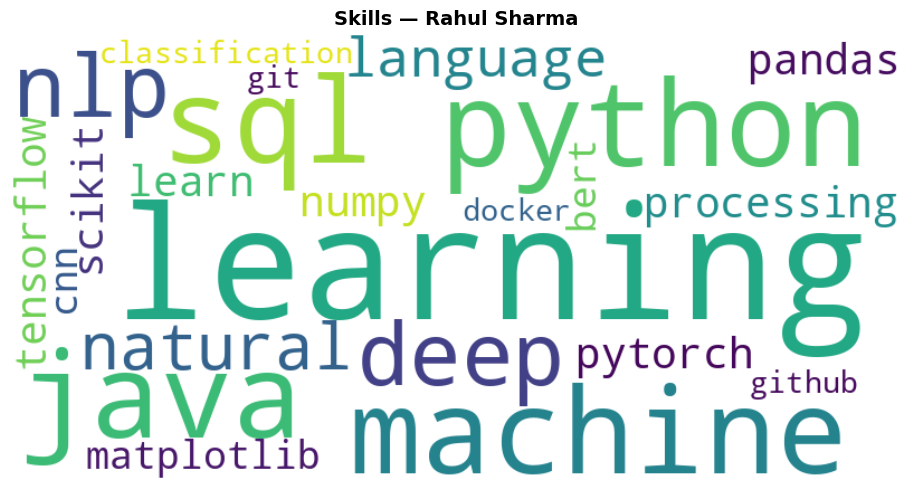

In [ ]:
top_skills = resume_parser.parse(SAMPLE_RESUME_1)['all_skills']
plot_skill_wordcloud(top_skills, f"Skills — {results[0]['candidate_name']}")

In [ ]:
df = pd.DataFrame([{
    'Rank':        r['rank'],
    'Candidate':   r['candidate_name'],
    'TF-IDF %':    r['tfidf_score'],
    'BERT %':      r['bert_score'],
    'Skill %':     r['skill_score'],
    'Exp %':       r['experience_score'],
    'FINAL %':     r['composite_score'],
    'Result':      r['label']
} for r in results])

display(df.style
    .set_table_styles([
        {'selector':'th','props':[('background','#2c3e50'),('color','white'),('padding','10px')]},
        {'selector':'td','props':[('padding','8px')]}
    ])
    .highlight_max(subset=['FINAL %'], color='#abebc6')
    .highlight_min(subset=['FINAL %'], color='#fadbd8')
)

,Rank,Candidate,TF-IDF %,BERT %,Skill %,Exp %,FINAL %,Result
0,1,Rahul Sharma,26.500000,56.740000,87.500000,100.000000,67.320000,🟡 Good Match
1,2,Priya Patel,10.010000,34.150000,43.750000,100.000000,39.750000,🟠 Partial Match
2,3,Amit Kumar,4.840000,52.300000,6.250000,100.000000,29.160000,🔴 Weak Match


In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# Text areas
resume_box = widgets.Textarea(
    value=SAMPLE_RESUME_1,
    placeholder='Paste resume text here...',
    layout=widgets.Layout(width='48%', height='300px')
)
jd_box = widgets.Textarea(
    value=SAMPLE_JD,
    placeholder='Paste job description here...',
    layout=widgets.Layout(width='48%', height='300px')
)
bulk_resume_box = widgets.Textarea(
    value=SAMPLE_RESUME_1+"\n---\n"+SAMPLE_RESUME_2+"\n---\n"+SAMPLE_RESUME_3,
    placeholder='Paste resumes separated by ---',
    layout=widgets.Layout(width='100%', height='300px')
)
bulk_jd_box = widgets.Textarea(
    value=SAMPLE_JD,
    placeholder='Paste job description...',
    layout=widgets.Layout(width='100%', height='150px')
)

output_single = widgets.Output()
output_bulk   = widgets.Output()

analyze_btn   = widgets.Button(description='🚀 Analyze Match',
    button_style='success', layout=widgets.Layout(width='200px', height='40px'))
bulk_btn      = widgets.Button(description='🚀 Screen All',
    button_style='success', layout=widgets.Layout(width='200px', height='40px'))

def on_analyze(b):
    with output_single:
        clear_output()
        rd = resume_parser.parse(resume_box.value)
        jd = jd_parser.parse(jd_box.value)
        r  = match_engine.compute_match_score(rd, jd)
        r['rank']  = 1
        r['label'], r['color'] = match_engine.get_screening_label(r['composite_score'])
        display_result_card(r)
        visualize_single_match(r, jd['title'])

def on_bulk(b):
    with output_bulk:
        clear_output()
        blocks = [b.strip() for b in bulk_resume_box.value.split('---') if b.strip()]
        jd     = jd_parser.parse(bulk_jd_box.value)
        rds    = [resume_parser.parse(b) for b in blocks]
        rnks   = match_engine.rank_candidates(rds, jd)
        for r in rnks:
            display_result_card(r)
        visualize_ranking(rnks, jd['title'])

analyze_btn.on_click(on_analyze)
bulk_btn.on_click(on_bulk)

# ── Layout ────────────────────────────────────────────────────
display(HTML("<h2 style='font-family:Arial;color:#2c3e50;'>🎯 Single Resume Match</h2>"))
display(widgets.HBox([resume_box, jd_box]))
display(analyze_btn)
display(output_single)

display(HTML("<hr><h2 style='font-family:Arial;color:#2c3e50;'>📋 Bulk Screening</h2>"))
display(HTML("<b>Job Description:</b>"))
display(bulk_jd_box)
display(HTML("<b>All Resumes (separate with ---):</b>"))
display(bulk_resume_box)
display(bulk_btn)
display(output_bulk)

Button(button_style='success', description='🚀 Analyze Match', layout=Layout(height='40px', width='200px'), sty…

Output()

Textarea(value='\nMachine Learning Engineer\nCompany: TechCorp India Pvt. Ltd. | Bangalore\n\nResponsibilities…

Textarea(value='\nRahul Sharma\nEmail: rahul.sharma@email.com | Phone: 9876543210\nGitHub: github.com/rahulsha…

Button(button_style='success', description='🚀 Screen All', layout=Layout(height='40px', width='200px'), style=…

Output()

In [ ]:
from google.colab import files

print("📤 Upload your resume (PDF, DOCX, or TXT)")
uploaded = files.upload()

if uploaded:
    filename = list(uploaded.keys())[0]
    text = extract_text(filename)
    print(f"\n✅ Extracted {len(text.split())} words")

    rd = resume_parser.parse(text)
    print(f"\n👤 Name       : {rd['name']}")
    print(f"📧 Email      : {rd['email']}")
    print(f"🎓 Education  : {rd['education']}")
    print(f"💼 Experience : {rd['experience_years']} years")
    print(f"🔧 Skills     : {rd['all_skills']}")

    jd  = jd_parser.parse(SAMPLE_JD)
    r   = match_engine.compute_match_score(rd, jd)
    r['rank']  = 1
    r['label'], r['color'] = match_engine.get_screening_label(r['composite_score'])
    display_result_card(r)
    visualize_single_match(r, jd['title'])
else:
    print("No file uploaded.")

📤 Upload your resume (PDF, DOCX, or TXT)


Saving Resume (5).pdf to Resume (5).pdf

✅ Extracted 278 words

👤 Name       : SNEHA YADAV
📧 Email      : Snehaayadav76@gmail.com
🎓 Education  : ['Bachelors']
💼 Experience : 0 years
🔧 Skills     : ['python', 'java', 'sql', 'machine learning', 'classification', 'html', 'css', 'aws', 'github', 'data analysis', 'data science', 'communication', 'teamwork', 'problem solving', 'analytical']


Metric,Score,Weight
🔵 TF-IDF Keyword Similarity,13.91%,20%
🟣 BERT Semantic Similarity,48.66%,30%
🟢 Skill Match Score,31.25%,40%
🟠 Experience Score,100.0%,10%
